<a href="https://colab.research.google.com/github/Khushibung05/NLP/blob/main/NLP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

# Path to the dataset (update if needed)
path = '/content/drive/My Drive/Colab Notebooks/spam.csv'

# Importing the dataset
df= pd.read_csv(path, encoding='latin-1')

# Keep only needed columns (dataset usually has extra unnamed columns)
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Shape
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5572, 2)


In [ ]:
#2. Count Spam vs Ham
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
#3. Average Message Length
# Create new column
df['length'] = df['message'].apply(len)

# Average length
print(df['length'].mean())

# By class
print(df.groupby('label')['length'].mean())

80.11880832735105
label
ham      71.023627
spam    138.866131
Name: length, dtype: float64


In [ ]:
#4. Word Frequency
# Clean Text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['clean_msg'] = df['message'].apply(clean_text)

In [ ]:
# Get Word Frequency
from collections import Counter

all_words = " ".join(df['clean_msg']).split()

word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('i', 3018), ('you', 2243), ('to', 2242), ('a', 1451), ('the', 1332), ('u', 1212), ('and', 979), ('in', 902), ('is', 890), ('me', 803)]


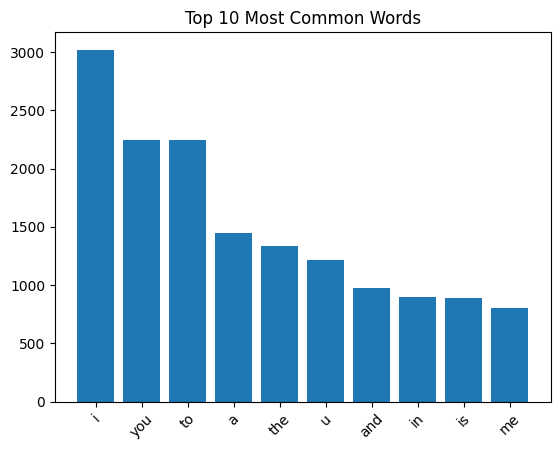

In [ ]:
#5. Plot Word Frequency
import matplotlib.pyplot as plt

common_words = word_freq.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Most Common Words")
plt.show()

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#pipeline
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Remove punctuation
    tokens = [word for word in tokens if word.isalpha()]

    # 4. Stopword removal
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join back
    cleaned_text = " ".join(tokens)

    return cleaned_text

In [ ]:
import nltk
nltk.download('punkt_tab')

#Apply on Dataset
df['processed'] = df['message'].apply(preprocess)

print(df[['message', 'processed']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                           processed  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts may...  
3                u dun say early hor u c already say  
4                nah think go usf life around though  


In [ ]:
#1. Split Data
from sklearn.model_selection import train_test_split

X = df['processed']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#2. Bag of Words (CountVectorizer)
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("BoW shape:", X_train_bow.shape)

BoW shape: (4457, 5910)


In [ ]:
#3. TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (4457, 5910)


In [ ]:
#4. Compare Feature Size
print("BoW features:", len(bow.vocabulary_))
print("TF-IDF features:", len(tfidf.vocabulary_))

BoW features: 5910
TF-IDF features: 5910


In [ ]:
#5. Check Sparsity
def sparsity(matrix):
    return 1.0 - (matrix.count_nonzero() / (matrix.shape[0] * matrix.shape[1]))

print("BoW sparsity:", sparsity(X_train_bow))
print("TF-IDF sparsity:", sparsity(X_train_tfidf))

BoW sparsity: 0.998713406201086
TF-IDF sparsity: 0.998713406201086


In [ ]:
#Model Comparison (Naive Bayes)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# BoW model
model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)
pred_bow = model_bow.predict(X_test_bow)

# TF-IDF model
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("BoW Accuracy:", accuracy_score(y_test, pred_bow))
print("TF-IDF Accuracy:", accuracy_score(y_test, pred_tfidf))

BoW Accuracy: 0.9748878923766816
TF-IDF Accuracy: 0.9659192825112107


In [ ]:
#1. Train Model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

Accuracy: 0.9443946188340807


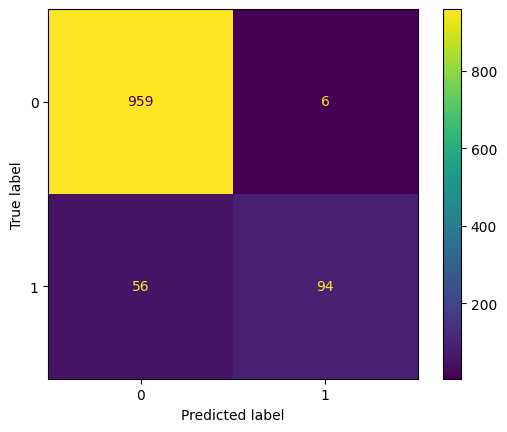

In [ ]:
#2. Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)
# 3. Accuracy
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
# 4. Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
#1. Import Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
# 2. Train Models
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Logistic Regression (already trained)
# lr_model

# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
# 3. Predictions
pred_nb = nb_model.predict(X_test_tfidf)
pred_lr = lr_model.predict(X_test_tfidf)
pred_svm = svm_model.predict(X_test_tfidf)
# 4. Evaluation Metrics
print("Naive Bayes\n", classification_report(y_test, pred_nb))
print("Logistic Regression\n", classification_report(y_test, pred_lr))
print("SVM\n", classification_report(y_test, pred_svm))
# 5. Clean Comparison Table
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, pos_label='spam'),
        recall_score(y_true, y_pred, pos_label='spam'),
        f1_score(y_true, y_pred, pos_label='spam')
    ]

results = pd.DataFrame({
    "Naive Bayes": evaluate(y_test, pred_nb),
    "Logistic Regression": evaluate(y_test, pred_lr),
    "SVM": evaluate(y_test, pred_svm)
}, index=["Accuracy", "Precision", "Recall", "F1"])

print(results)

Naive Bayes
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115

Logistic Regression
               precision    recall  f1-score   support

         ham       0.94      0.99      0.97       965
        spam       0.94      0.63      0.75       150

    accuracy                           0.94      1115
   macro avg       0.94      0.81      0.86      1115
weighted avg       0.94      0.94      0.94      1115

SVM
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.97      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.92      0.95      1115
weighted avg       0.98      0.98  

🧠 TASK 6 — Hyperparameter Tuning
Use:
GridSearchCV
Tune:
C (Logistic Regression)
kernel (SVM)
📊 TASK 7 — Advanced Feature Engineering
Implement:
N-grams (bigram, trigram)
Compare performance:
ngram_range=(1,2)
ngram_range=(1,3)
🧩 TASK 8 — Word Embeddings (Word2Vec)
Tasks
Train Word2Vec model
Convert sentences → vectors (average embeddings)
Train classifier
😊 TASK 9 — Sentiment Analysis
Add new feature:
Sentiment score using TextBlob or VADER
Combine with TF-IDF.
🏷️ TASK 10 — Named Entity Recognition (NER)
Extract entities from messages:
Names
Organizations
Locations
Use:
spaCy
🔤 TASK 11 — Part-of-Speech Analysis
Tasks
Extract POS tags
Find most common verbs/nouns in spam
🔮 TASK 12 — Language Model (N-gram)
Build:
Bigram model to predict next word.
Example:
"win money now" → predict next word


In [ ]:
#Logistic Regression (tuning C)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)
# SVM (tuning kernel)
from sklearn.svm import SVC

param_svm = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=3,
    scoring='f1'
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM Params:", grid_svm.best_params_)

#TASK 7 — Advanced Feature Engineering (N-grams)
# Bigram (1,2)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bigram = TfidfVectorizer(ngram_range=(1,2))

X_train_bg = tfidf_bigram.fit_transform(X_train)
X_test_bg = tfidf_bigram.transform(X_test)
# Trigram (1,3)
tfidf_trigram = TfidfVectorizer(ngram_range=(1,3))

X_train_tg = tfidf_trigram.fit_transform(X_train)
X_test_tg = tfidf_trigram.transform(X_test)
# Compare Performance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

# Bigram
model.fit(X_train_bg, y_train)
pred_bg = model.predict(X_test_bg)

# Trigram
model.fit(X_train_tg, y_train)
pred_tg = model.predict(X_test_tg)

print("Bigram Acc:", accuracy_score(y_test, pred_bg))
print("Trigram Acc:", accuracy_score(y_test, pred_tg))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

Best LR Params: {'C': 0.01}
Best LR Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

Best SVM Params: {'C': 0.1, 'kernel': 'linear'}
Bigram Acc: 0.9479820627802691
Trigram Acc: 0.9434977578475336


In [ ]:
Train Word2Vec
from gensim.models import Word2Vec

tokenized = [text.split() for text in df['processed']]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=1
)
📌 Sentence → Vector (Average)
import numpy as np

def get_vector(text):
    words = text.split()
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_w2v = np.array([get_vector(text) for text in df['processed']])
📌 Train Classifier
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_w2v, y_train)

print("W2V Accuracy:", model.score(X_test_w2v, y_test))
🧠 Insight
Captures semantic meaning
Better for deep NLP tasks than BoW
😊 TASK 9 — Sentiment Analysis
📌 Using TextBlob
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['message'].apply(get_sentiment)
📌 Combine with TF-IDF
import numpy as np
from scipy.sparse import hstack

X_combined = hstack((X_train_tfidf, df.loc[X_train.index, ['sentiment']].values))
🧠 Insight
Spam often has strong positive tone
Adds extra signal to model
🏷️ TASK 10 — Named Entity Recognition (NER)
📌 Using spaCy
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df['message'].apply(extract_entities)

print(df['entities'].head())
🧠 Example Output
[('Amazon', 'ORG'), ('India', 'GPE')]
🔤 TASK 11 — Part-of-Speech (POS)
📌 Extract POS Tags
from collections import Counter

def get_pos(text):
    doc = nlp(text)
    return [token.pos_ for token in doc]

df['pos'] = df['message'].apply(get_pos)
📊 Most Common POS in Spam
spam_pos = Counter([pos for row in df[df['label']=='spam']['pos'] for pos in row])

print(spam_pos.most_common(10))
🧠 Insight
Spam → more verbs (buy, win)
Ham → more nouns/pronouns
🔮 TASK 12 — N-gram Language Model (Bigram)
📌 Build Bigram Model
from collections import defaultdict

bigram_model = defaultdict(lambda: defaultdict(int))

for text in df['processed']:
    words = text.split()
    for i in range(len(words)-1):
        bigram_model[words[i]][words[i+1]] += 1
📌 Predict Next Word
def predict_next(word):
    if word not in bigram_model:
        return None

    next_words = bigram_model[word]
    return max(next_words, key=next_words.get)

print(predict_next("win"))